In [1]:
import os
import sys
import json
import pandas as pd
import numpy as np

sys.path.insert(0, '../data_processing/palette/')
sys.path.insert(0, '../data_processing/util/')

from palette import Palette
from util import array_to_schematic

INFO - PyMCTranslate Version 385


In [2]:
data_path = '../data/'
samples_path = os.path.join(data_path, 'new_data/java/')
block_palette_path = os.path.join(data_path, 'java_palette.json')
sample_df_path = os.path.join(data_path, 'new_samples_metadata.csv')

samples = os.listdir(samples_path)

In [3]:
# Retrieve the metadata for all samples
metadata_df = pd.read_csv(sample_df_path)
metadata_df = metadata_df[metadata_df.volume.notna()] #Exclude rows of samples that weren't processed

# Retrieve the block-token mapping
with open(block_palette_path) as f:
    block2token = json.load(f)

In [4]:
# Load the blocks into Palette class
block_palette = Palette(block2token)

Added 556 blocks for potential tranformations


In [5]:
# Get the reduced block mapping. i.e. oak_log[axis=x] & oak_log[axis=y] => oak_log
keep_blockstates = [] # Dont keep any blockstates
reduced_block_palette, src2tgt, tgt2src = block_palette.reduce_blockstates(keep_blockstates=keep_blockstates)

Added 0 blocks for potential tranformations


## Distribution 1: Block counts across dataset

In [6]:
# Create Dataframe to fill
block_dist_dataframe = pd.DataFrame(columns=["Block", "total_occurences", "sample_occurences"])

In [7]:
# Count instances of each block occurs in the entire dataset
block_counts = np.zeros(len(reduced_block_palette), dtype=np.int64)

# These two are used in distribution 3, but are convenient to collect now
# -- Number of samples each block occurs in
sample_counts_per_block = np.zeros(len(reduced_block_palette), dtype=np.int64)

# -- Per Sample, how many times each block occurs
block_counts_per_sample = np.zeros( (len(metadata_df), len(reduced_block_palette)), dtype=np.int64)

# Iterate though samples, recording the block occurences & how many samples blocks occur in
for i, row in enumerate(metadata_df.itertuples()):
    # Load the Sample
    sample_name = row.filename
    sample_path = os.path.join(samples_path, f'{sample_name}_java.npy')
    sample_array = np.load(sample_path)
    
    # Map the array to the reduced blockstate
    sample_reduced_block_array = src2tgt[sample_array]
    
    # Get the value counts
    blocks, counts = np.unique(sample_reduced_block_array, return_counts=True)
    
    #-- Add counts to block_occurences
    block_counts[blocks] += counts
    
    #--Increment sample_counts_per_block for every block that does appear in this sample
    sample_counts_per_block[blocks] += 1
    
    block_counts_this_sample = np.zeros(len(reduced_block_palette), dtype=np.int64)
    block_counts_this_sample[blocks] += counts
    
    block_counts_per_sample[i] = block_counts_this_sample

In [32]:
# Create dataframe to store these distributions
block_dist_dataframe = pd.DataFrame(columns=["Block", "total_occurences", "sample_occurences"])

# Add data
for i in range(len(block_counts)):
    row = {
        "Block": reduced_block_palette.token2block[i],
        "total_occurences": block_counts[i],
        "sample_occurences": sample_counts_per_block[i]
    }
    block_dist_dataframe.loc[i] = row

block_counts_per_sample_df = pd.DataFrame(block_counts_per_sample, index=metadata_df["filename"].tolist(), columns=reduced_block_palette.block_strings)
block_counts_per_sample_df = block_counts_per_sample_df.reset_index(names="Sample")


## Distribution 2: Sample Volumes

In [12]:
# Distribution 1: Sample Volumes
sample_dims_dataframe = metadata_df[["filename", "volume", "x", "y", "z"]].rename(columns={"filename": "Sample"})
volumes_arr = np.array(metadata_df["volume"], dtype=np.int64)

## Distribution 3: Block & Sample Density Score
### First, block rarity scores are computed with log( Sum of sample volumes / block type count )

In [ ]:
N = volumes_arr.sum()
log_rarity = np.log( 1 + (N / (block_counts)) )

In [14]:
print(f'max: {log_rarity.max()}')
print(f'max: {log_rarity.min()}')
print(f'max: {log_rarity.mean()}')

print()
for block, token in reduced_block_palette.block2token.items():
    print(f'{block}: {log_rarity[token]}')

max: 22.979570692946844
max: 0.9142578987871649
max: 14.201012421480627

minecraft:air: 0.9142578987871649
minecraft:dirt: 3.1526870356344165
minecraft:grass_block: 4.376058993998479
minecraft:coarse_dirt: 8.78295499356643
minecraft:green_concrete: 11.27248193184296
minecraft:green_wool: 9.802257546407748
minecraft:cyan_terracotta: 8.783791208649294
minecraft:oak_leaves: 5.437749253976232
minecraft:dark_oak_leaves: 7.329418533759713
minecraft:green_glazed_terracotta: 13.051782994046974
minecraft:grass: 6.507165607593132
minecraft:spruce_planks: 8.04263828880374
minecraft:oak_log: 7.503686707710452
minecraft:brick_stairs: 10.58723875646009
minecraft:oak_slab: 9.685653362158067
minecraft:spruce_stairs: 9.540404903096386
minecraft:spruce_slab: 9.566533471297037
minecraft:flower_pot: 12.784162878444196
minecraft:yellow_stained_glass: 12.542023193371426
minecraft:birch_leaves: 6.7729646821871325
minecraft:lime_stained_glass: 12.204209181141191
minecraft:white_carpet: 11.475232286802417
mine

### Next, we get the summed block rarities for each sample in the dataset
#### #Samples = S, #Blocks = B | SxB x Bx1 = Sx1

In [15]:
sample_weighted_volumes = block_counts_per_sample @ log_rarity

sample_weigted_densities = sample_weighted_volumes / volumes_arr

## Visualizations

### Block counts across dataset

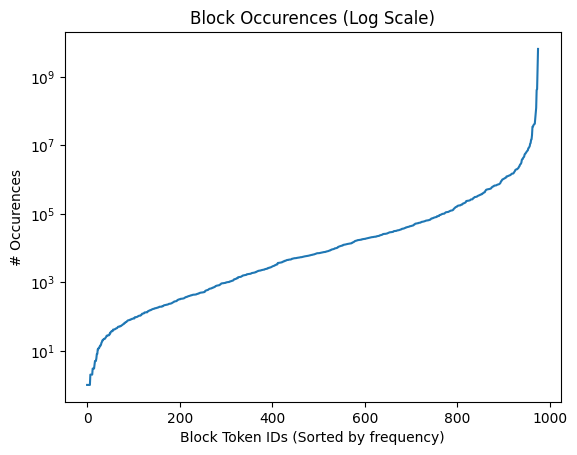

In [16]:
import matplotlib.pyplot as plt
import scipy

block_counts_dist = np.sort(block_counts)
sample_counts_per_block_dist = np.sort(sample_counts_per_block)

fig, ax = plt.subplots()

# Styling
ax.set_title("Block Occurences (Log Scale)")
ax.set_ylabel("# Occurences")
ax.set_xlabel("Block Token IDs (Sorted by frequency)")


ax.plot(block_counts_dist)
ax.set_yscale('log')

In [17]:
threshold = 9000
blocks_mask = block_counts < threshold
block_strings = []
for i, mask in enumerate(blocks_mask):
    if mask:
        block_strings.append(reduced_block_palette.token2block[i])

keep_blockstates = ["axis", "facing", "shape", "east", "west", "north", "south", "face", "half"]
orientation_only_palette, src2tgt, tgt2src = block_palette.reduce_blockstates(keep_blockstates)

air_mask = orientation_only_palette.get_mask_lookup(block_strings)

Added 0 blocks for potential tranformations


In [18]:
data_path = '../data/new_data/java/'
sample = 'build_batch_1_22_8_java.npy'
sample = 'build_batch_22_554_1_java.npy'

sample_path = os.path.join(data_path, sample)

build_arr = np.load(sample_path)

reduced_build_arr = src2tgt[build_arr]
masked_build_arr = air_mask[reduced_build_arr]

masked_build_game_format = tgt2src[masked_build_arr]

array_to_schematic(masked_build_game_format, block_palette.token2block, '../', filename="test_mask")

Successfully saved schematic to test_mask.schem


### Block Rarity Scores

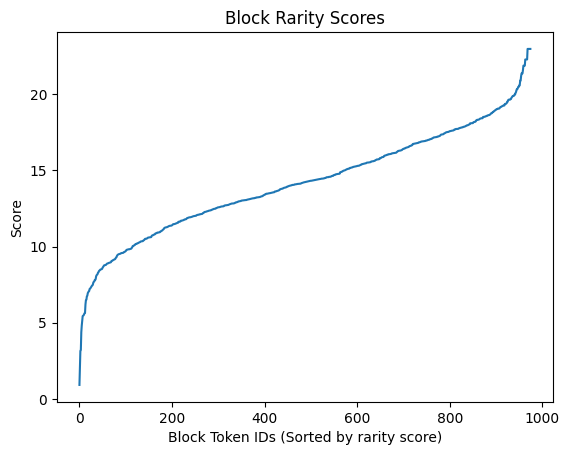

In [19]:
block_rarity_dist = np.sort(log_rarity)

fig, ax = plt.subplots()

# Styling
ax.set_title("Block Rarity Scores")
ax.set_ylabel("Score")
ax.set_xlabel("Block Token IDs (Sorted by rarity score)")

ax.plot(block_rarity_dist)

### Sample Volumes

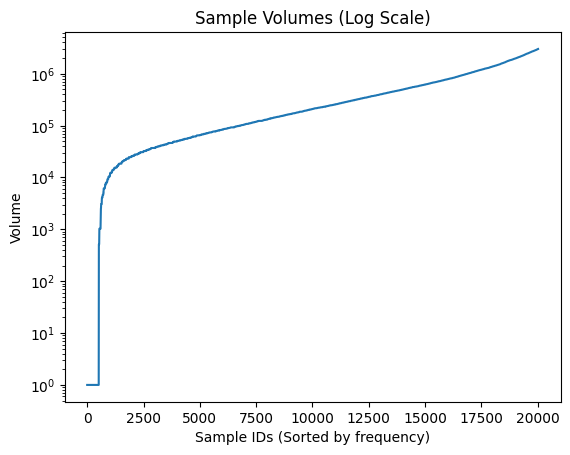

In [20]:
volume_dist = np.sort(volumes_arr)

fig, ax = plt.subplots()

ax.set_title("Sample Volumes (Log Scale)")
ax.set_ylabel("Volume")
ax.set_xlabel("Sample IDs (Sorted by frequency)")

ax.plot(volume_dist)
ax.set_yscale('log')

<bound method Figure.show of <Figure size 640x480 with 1 Axes>>

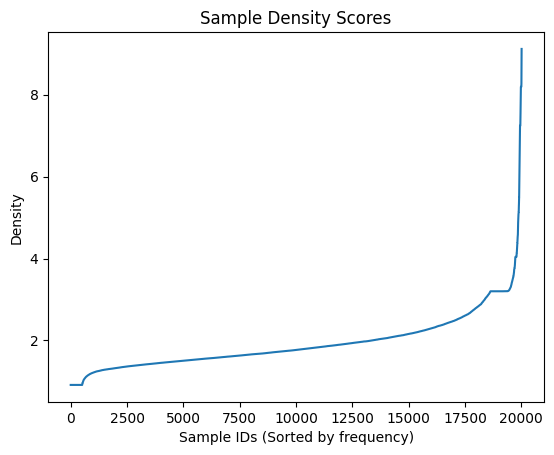

In [21]:
sample_weigted_densities_dist = np.sort(sample_weigted_densities)

fig, ax = plt.subplots()
# Styling
ax.set_title("Sample Density Scores")
ax.set_ylabel("Density")
ax.set_xlabel("Sample IDs (Sorted by frequency)")

ax.plot(sample_weigted_densities_dist)
# ax.set_yscale('log')
fig.show

### Save Data

In [25]:
data_analysis_path = '.'
block_dist_dataframe_path = os.path.join(data_analysis_path, 'block_dist_dataframe.csv')
sample_dims_dataframe_path = os.path.join(data_analysis_path, 'sample_dims_dataframe.csv')
block_counts_per_sample_df_path = os.path.join(data_analysis_path, 'block_counts_per_sample_dataframe.csv')

In [26]:
block_dist_dataframe["log_rarity"] = log_rarity
sample_dims_dataframe["density"] = sample_weigted_densities

In [33]:
block_dist_dataframe.to_csv(block_dist_dataframe_path, index=False)
sample_dims_dataframe.to_csv(sample_dims_dataframe_path, index=False)
block_counts_per_sample_df.to_csv(block_counts_per_sample_df_path, index=False)